# Explore the prototype graph (CSV → analysis → NetworkX)

This notebook loads **`data/processed/nodes.csv`** and **`data/processed/edges.csv`** built from the synthetic seed under **`data/interim/poc_v1_seed/`** by `src/graph_build/build_graph_files.py`.

**Prerequisite:** from the project root, run:

```bash
python src/graph_build/build_graph_files.py
```

**Working directory:** run Jupyter from the **project root**, or from `notebooks/` — the path helper below searches upward for `data/processed/nodes.csv`.

## 1. Load the node and edge tables

Each row in `nodes.csv` is one entity (person, policy, claim, …). Each row in `edges.csv` is a **directed** link from `source_node_id` to `target_node_id`.

In [8]:
from pathlib import Path

import pandas as pd


def find_project_root() -> Path:
    """Locate repo root by finding data/processed/nodes.csv."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / "processed" / "nodes.csv"
        if candidate.is_file():
            return folder
    raise FileNotFoundError(
        "Could not find data/processed/nodes.csv. Run build_graph_files.py from the project root first."
    )


ROOT = find_project_root()
nodes_path = ROOT / "data" / "processed" / "nodes.csv"
edges_path = ROOT / "data" / "processed" / "edges.csv"

nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)

print(f"Loaded {len(nodes_df)} nodes from {nodes_path}")
print(f"Loaded {len(edges_df)} edges from {edges_path}")

Loaded 19 nodes from /Users/iagolarrondo/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/1. Coursework and academic/Y2 ('25-'26) - IAP, H3 & H4/15.S04 – Gen AI Lab/2. Assignments and deliverables/Manulife Project/data/processed/nodes.csv
Loaded 22 edges from /Users/iagolarrondo/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/1. Coursework and academic/Y2 ('25-'26) - IAP, H3 & H4/15.S04 – Gen AI Lab/2. Assignments and deliverables/Manulife Project/data/processed/edges.csv


## 2. Sample rows from `nodes.csv` and `edges.csv`

A quick look at the CSV **schema** and a few rows. `properties_json` stores extra fields as one JSON string per row.

In [9]:
from IPython.display import display

print("=== Sample nodes (first 8 rows) ===")
display(nodes_df.head(8))

print("\n=== Sample edges (first 10 rows) ===")
display(edges_df.head(10))

=== Sample nodes (first 8 rows) ===


,node_id,node_type,label,source_table,properties_json
0,person_5001,Person,JANE DOE,T_RESOLVED_PERSON,"{""RES_PERSON_ID"": 5001, ""FIRST_NAME"": ""JANE"", ..."
1,person_5002,Person,JOHN DOE,T_RESOLVED_PERSON,"{""RES_PERSON_ID"": 5002, ""FIRST_NAME"": ""JOHN"", ..."
2,person_5003,Person,MARIA GARCIA,T_RESOLVED_PERSON,"{""RES_PERSON_ID"": 5003, ""FIRST_NAME"": ""MARIA"",..."
3,person_5004,Person,ROBERT CHEN,T_RESOLVED_PERSON,"{""RES_PERSON_ID"": 5004, ""FIRST_NAME"": ""ROBERT""..."
4,person_5005,Person,SAM LEE,T_RESOLVED_PERSON,"{""RES_PERSON_ID"": 5005, ""FIRST_NAME"": ""SAM"", ""..."
5,business_7001,Business,RESOLVE CARE HHCA LLC,T_RESOLVED_BUSINESS,"{""RES_BUSINESS_ID"": 7001, ""BUSINESS_NAME"": ""RE..."
6,business_7002,Business,NORTH SHORE NURSING LLC,T_RESOLVED_BUSINESS,"{""RES_BUSINESS_ID"": 7002, ""BUSINESS_NAME"": ""NO..."
7,policy_POL-LTC-10001,Policy,POL-LTC-10001,T_NORM_POLICY,"{""COMPANY_CODE"": ""JH"", ""POLICY_NUMBER"": ""POL-L..."



=== Sample edges (first 10 rows) ===


,edge_id,source_node_id,target_node_id,edge_type,source_table,properties_json
0,e_000000,person_5001,address_9001,LOCATED_IN,T_RESOLVED_PERSON_ADDRESS_CROSSWALK,"{""RES_PERSON_ID"": 5001, ""EDGE_NAME"": ""LOCATED_..."
1,e_000001,person_5002,address_9001,LOCATED_IN,T_RESOLVED_PERSON_ADDRESS_CROSSWALK,"{""RES_PERSON_ID"": 5002, ""EDGE_NAME"": ""LOCATED_..."
2,e_000002,person_5003,address_9001,LOCATED_IN,T_RESOLVED_PERSON_ADDRESS_CROSSWALK,"{""RES_PERSON_ID"": 5003, ""EDGE_NAME"": ""LOCATED_..."
3,e_000003,person_5004,address_9001,LOCATED_IN,T_RESOLVED_PERSON_ADDRESS_CROSSWALK,"{""RES_PERSON_ID"": 5004, ""EDGE_NAME"": ""LOCATED_..."
4,e_000004,person_5005,address_9002,LOCATED_IN,T_RESOLVED_PERSON_ADDRESS_CROSSWALK,"{""RES_PERSON_ID"": 5005, ""EDGE_NAME"": ""LOCATED_..."
5,e_000005,business_7001,address_9001,LOCATED_IN,T_RESOLVED_BUSINESS_ADDRESS_CROSSWALK,"{""RES_BUSINESS_ID"": 7001, ""RES_ADDRESS_ID"": 9001}"
6,e_000006,business_7002,address_9003,LOCATED_IN,T_RESOLVED_BUSINESS_ADDRESS_CROSSWALK,"{""RES_BUSINESS_ID"": 7002, ""RES_ADDRESS_ID"": 9003}"
7,e_000007,person_5001,person_5002,IS_SPOUSE_OF,T_RESOLVED_PERSON_PERSON_CROSSWALK,"{""RES_PERSON_ID_SRC"": 5001, ""EDGE_NAME"": ""IS_S..."
8,e_000008,person_5002,person_5004,IS_RELATED_TO,T_RESOLVED_PERSON_PERSON_CROSSWALK,"{""RES_PERSON_ID_SRC"": 5002, ""EDGE_NAME"": ""IS_R..."
9,e_000009,person_5003,person_5001,IS_RELATED_TO,T_RESOLVED_PERSON_PERSON_CROSSWALK,"{""RES_PERSON_ID_SRC"": 5003, ""EDGE_NAME"": ""IS_R..."


## 3. Node counts by type

How many **Person**, **Policy**, **Claim**, etc. nodes are in this build.

node_type
Address        3
BankAccount    3
Business       2
Claim          4
Person         5
Policy         2


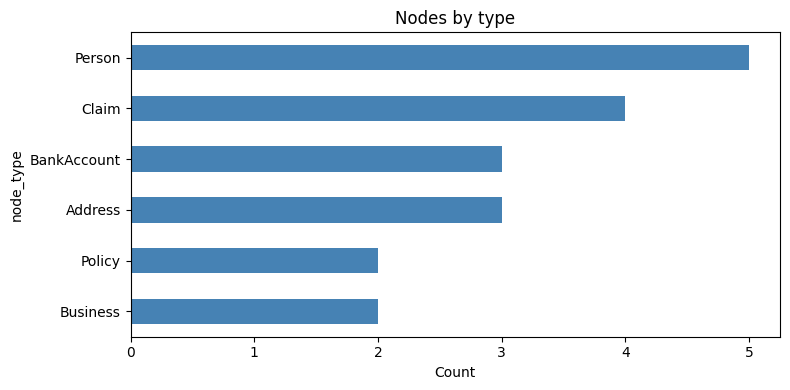

In [10]:
import matplotlib.pyplot as plt

node_counts = nodes_df["node_type"].value_counts().sort_index()
print(node_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
node_counts.sort_values(ascending=True).plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Nodes by type")
plt.tight_layout()
plt.show()

## 4. Edge counts by relationship type

Each `edge_type` matches the crosswalk / synthesized relationship vocabulary (e.g. `IS_COVERED_BY`, `LOCATED_IN`, `HOLD_BY`). See `docs/poc_v1_graph_mapping.md`.

edge_type
HOLD_BY                    4
IS_CLAIM_AGAINST_POLICY    4
IS_COVERED_BY              3
IS_RELATED_TO              2
IS_SPOUSE_OF               1
LOCATED_IN                 7
SOLD_POLICY                1


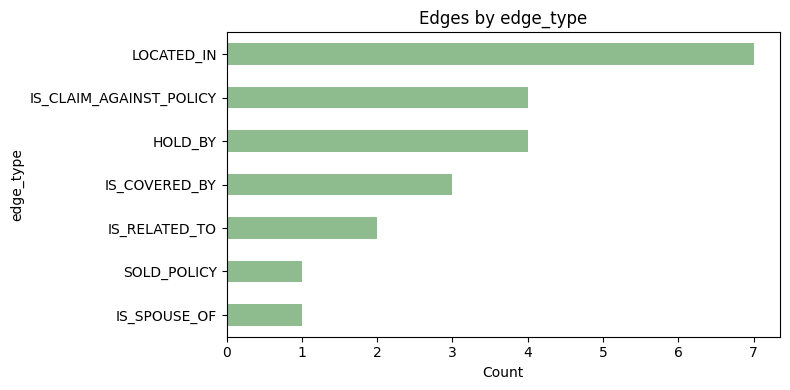

In [11]:
edge_counts = edges_df["edge_type"].value_counts().sort_index()
print(edge_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
edge_counts.sort_values(ascending=True).plot(kind="barh", ax=ax, color="darkseagreen")
ax.set_xlabel("Count")
ax.set_title("Edges by edge_type")
plt.tight_layout()
plt.show()

## 5. Build a NetworkX graph

We use a **`DiGraph`** (directed) because the CSV has explicit source → target direction. Downstream sections use this object for **degree** and **connected components**.

In [12]:
import networkx as nx

G = nx.DiGraph()

for _, row in nodes_df.iterrows():
    G.add_node(
        row["node_id"],
        node_type=row["node_type"],
        label=row["label"],
        source_table=row["source_table"],
        properties_json=row["properties_json"],
    )

for _, row in edges_df.iterrows():
    G.add_edge(
        row["source_node_id"],
        row["target_node_id"],
        edge_id=row["edge_id"],
        edge_type=row["edge_type"],
        source_table=row["source_table"],
        properties_json=row["properties_json"],
    )

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} directed edges")

Graph: 19 nodes, 22 directed edges


## 6. Nodes with the highest degree

For a **directed** graph, **total degree** = in-degree + out-degree (how many edge ends touch the node). High-degree nodes are natural **hubs** in the prototype: many policies, shared addresses, or people who sit in the middle of several relationship types.

We also show **in** vs **out** so you can see whether a node mostly *receives* links (e.g. a policy many claims point to) or *sends* them.

In [13]:
rows = []
for n in G.nodes():
    inn = G.in_degree(n)
    out = G.out_degree(n)
    rows.append(
        {
            "node_id": n,
            "node_type": G.nodes[n].get("node_type", ""),
            "label": G.nodes[n].get("label", ""),
            "in_degree": inn,
            "out_degree": out,
            "total_degree": inn + out,
        }
    )

deg_df = pd.DataFrame(rows).sort_values("total_degree", ascending=False)
print("Top 12 nodes by total degree:")
display(deg_df.head(12))

Top 12 nodes by total degree:


,node_id,node_type,label,in_degree,out_degree,total_degree
7,policy_POL-LTC-10001,Policy,POL-LTC-10001,6,0,6
1,person_5002,Person,JOHN DOE,1,5,6
0,person_5001,Person,JANE DOE,1,4,5
13,address_9001,Address,"BOSTON, MA",5,0,5
2,person_5003,Person,MARIA GARCIA,0,4,4
3,person_5004,Person,ROBERT CHEN,1,1,2
4,person_5005,Person,SAM LEE,0,2,2
16,bank_8001,BankAccount,Bank 8001 (****9921),2,0,2
8,policy_POL-LTC-10002,Policy,POL-LTC-10002,2,0,2
17,bank_8002,BankAccount,Bank 8002 (****4410),1,0,1


## 7. Connected components (weakly connected)

If we **ignore edge direction**, a **weakly connected component** is a maximal set of nodes linked by any path. In investigation tooling this often matches an intuitive **“cluster”** of parties and artifacts that can reach each other through the graph.

- **One large component** usually means the seed scenario is a single intertwined story (household + policies + claims + shared resources).
- **Several components** would mean isolated islands (e.g. a person with no crosswalks yet).

*Note:* Strongly connected components (respecting direction) are stricter; for PoC exploration, weakly connected is usually easier to interpret.

In [14]:
comps = list(nx.weakly_connected_components(G))
comps_sorted = sorted(comps, key=len, reverse=True)

print(f"Number of weakly connected components: {len(comps_sorted)}")
for i, comp in enumerate(comps_sorted, start=1):
    print(f"\n--- Component {i} (size {len(comp)}) ---")
    # Summarize by node_type
    types = {}
    for nid in comp:
        t = G.nodes[nid].get("node_type", "?")
        types[t] = types.get(t, 0) + 1
    print("Counts by type:", dict(sorted(types.items())))
    # List node ids (compact)
    members = sorted(comp)
    if len(members) <= 25:
        for nid in members:
            lab = G.nodes[nid].get("label", "")
            print(f"  {nid}  ({G.nodes[nid].get('node_type', '')})  {lab}")
    else:
        print("  (too many to list; showing first 15)")
        for nid in members[:15]:
            print(f"  {nid}  ({G.nodes[nid].get('node_type', '')})")
        print(f"  ... and {len(members) - 15} more")

Number of weakly connected components: 2

--- Component 1 (size 17) ---
Counts by type: {'Address': 2, 'BankAccount': 3, 'Business': 1, 'Claim': 4, 'Person': 5, 'Policy': 2}
  address_9001  (Address)  BOSTON, MA
  address_9002  (Address)  QUINCY, MA
  bank_8001  (BankAccount)  Bank 8001 (****9921)
  bank_8002  (BankAccount)  Bank 8002 (****4410)
  bank_8003  (BankAccount)  Bank 8003 (****7733)
  business_7001  (Business)  RESOLVE CARE HHCA LLC
  claim_C9000000001  (Claim)  CLM-2024-00091
  claim_C9000000002  (Claim)  CLM-2024-00102
  claim_C9000000003  (Claim)  CLM-2024-00115
  claim_C9000000004  (Claim)  CLM-2023-08880
  person_5001  (Person)  JANE DOE
  person_5002  (Person)  JOHN DOE
  person_5003  (Person)  MARIA GARCIA
  person_5004  (Person)  ROBERT CHEN
  person_5005  (Person)  SAM LEE
  policy_POL-LTC-10001  (Policy)  POL-LTC-10001
  policy_POL-LTC-10002  (Policy)  POL-LTC-10002

--- Component 2 (size 2) ---
Counts by type: {'Address': 1, 'Business': 1}
  address_9003  (Address

## 8. What this means for an investigation prototype

In plain terms:

- **Tables → graph:** The CSVs are a bridge between warehouse-style extracts and a **link chart** mental model. Investigators care about *who* connects to *what* (policy, claim, address, bank account, business), not just row counts.

- **Counts by type:** Show whether the slice is **people-heavy**, **claim-heavy**, etc. A PoC that mixes parties, financial instruments, and locations mirrors how SIU and special-investigation teams actually triage.

- **Counts by edge type:** Surface **which relationships** dominate (`LOCATED_IN`, `IS_COVERED_BY`, `HOLD_BY`, …). Spikes or odd combinations (e.g. many `HOLD_BY` vs few people) hint at **shared payout paths** or **networked exposure** worth drilling into.

- **High-degree nodes:** These are **hubs**. A policy with many claims, an address with many people, or a person with many roles (insured + agent + claimant in real data) shows up here first. Product workflows can **start from hubs** or **flag them** in a UI.

- **Weakly connected components:** A single big component means “everything in this extract is one **story**.” Multiple components mean **disconnected leads**—either missing data in the extract or genuinely separate cases. For **InvestigAI / text-to-graph**, the goal is often to grow one component by resolving entities and adding edges until the narrative is connected.

This notebook is intentionally small: it validates the **build**, teaches the **schema**, and gives **structural** summaries you can extend with path queries, subgraph exports, or richer visuals later.

## 9. Optional: spring layout plot

A quick **matplotlib** view (not geographic). Colors follow `node_type`. For larger graphs, prefer filtering to a subgraph or using dedicated graph tools.

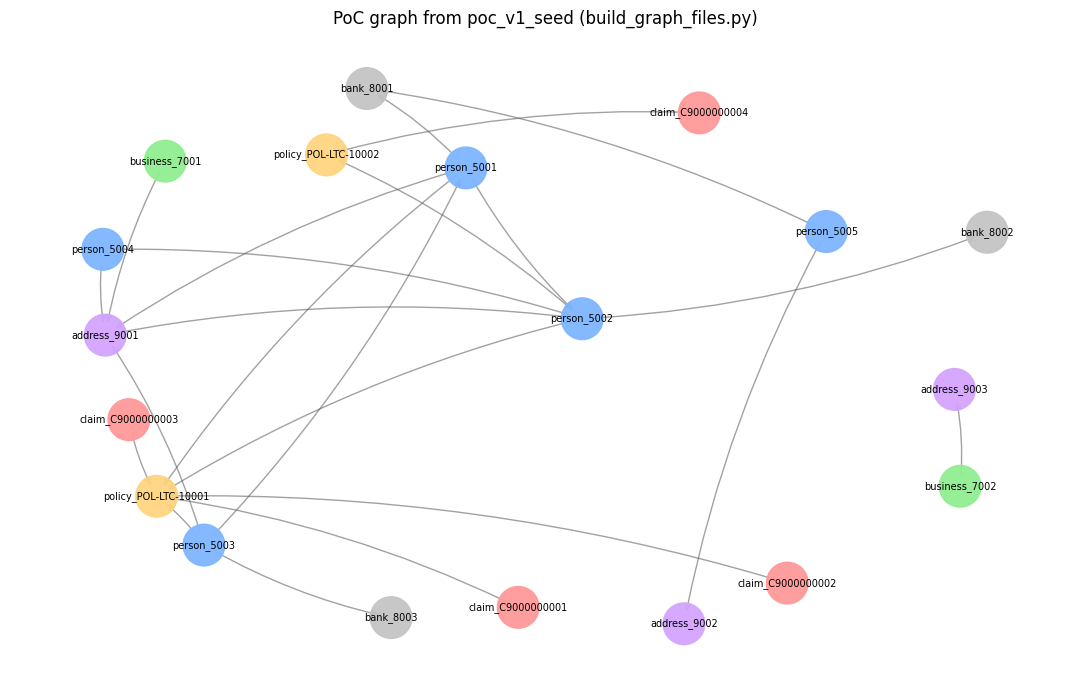

In [15]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize=(11, 7))

pos = nx.spring_layout(G, seed=42, k=1.8)

type_colors = {
    "Person": "#7eb6ff",
    "Business": "#90ee90",
    "Policy": "#ffd580",
    "Claim": "#ff9999",
    "Address": "#d4a5ff",
    "BankAccount": "#c4c4c4",
}
node_colors = [type_colors.get(G.nodes[n]["node_type"], "#eeeeee") for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=7)
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=12,
    edge_color="#555555",
    alpha=0.55,
    connectionstyle="arc3,rad=0.08",
)

plt.title("PoC graph from poc_v1_seed (build_graph_files.py)")
plt.axis("off")
plt.tight_layout()
plt.show()